# Week 1: Equipment, Laboratory space, and Resistance

Your Name:  <span style="background-color:yellow">Cole Stevens</span>
<br>

Throughout the lab, all of your answers in markdown cells should be highlighted in yellow.

## Equipment walkthrough
* Breadboard storage: each student has a breadboard
* Equipment in drawer at each station: scissors, ruler, wire cutters, pliers, chip tweezers, resistor color code chart, breadboard wires, leads
* Instruments at each station: ps, dmm, sig gen, oscilloscope
* Equipment at front/side: parts bins, leads, coax cables, etc.
* Computer at each station

## Laboratory space
* **SAFETY**
    * Exit through lab doors to hallway (green signs), then left to external stairway. The door to the stockroom (to the left of the fume hood at the front) is usually locked and does *not* lead directly out.
    * Eyewash station and sink in front of room
    * First aid kit near sink
* Printer in corner near fume hood

## Computer environment: loading packages
Now that we are going to use the computer we will `import` the relevant plotting, mathematical, scientific, and instrument libraries. The first few are familiar from your plotting and fitting exercises. There is an additional one for instruments.  

**The `import pyvisa` command must be executed _before_ communicating with instruments.**

In [3]:
import matplotlib.pyplot as plt   # plotting
import numpy as np                # arrays
import scipy as sp      # fitting
import pyvisa                     # instrument communication
import pandas as pd               # importing/exporting data

ModuleNotFoundError: No module named 'pyvisa'

## Determine resistance: color bands
Because resistors are small and many times inaccessible a color code has been developed so you can *see* the resistance value.  A color code legend is located in your drawer and near the resistor bins.

* Pick a resistor from the parts bin, look at its color code and determine its resistance.  For example, if the colors were brown/black/brown that corresponds to about 100 $\Omega$.

### EXERCISE 1: Resistance color bands
According to the color bands, what is the resistance or your resistor?
In the cell below indicate your colors and the expected resistance. For example, "brown, black, brown" is expected to be "100 ohms."

Resistance (color bands):  <span style="background-color:yellow">red/red/red - 2.2k$\ohm$</span>

## Determine resistance: "ohmmeter" (DMM)
We can measure the resistance directly by using an "ohmmeter".  At your station is a **D**igital **M**ulti**m**eter (**DMM**) which is  capable of measuring many quantities: resistance, voltage (DC/AC), current (DC/AC), frequency, etc.  The specific measurement is determined by the input terminals and the settings. (This is quite similar to the DMM in your kit.)

* Using appropriate leads (wires) connect your resistor to the DMM and determine the resistance manually (i.e. without controlling the DMM remotely).

### EXERCISE 2: Resistance with "ohmmeter" (manual)
In the cell below indicate the measured resistance of your resistor.

Resistance (DMM, manual):  <span style="background-color:yellow">2.2025k$\ohm$</span>

# Measure resistance: I-V curve (by hand)
The standard (and widespread) technique for measuring the "resistance" is to determine the characteristic I-V curve for a circuit element. Using various combinations of power supplies, voltmeters, and ammeters you simultaneously measure the *current through* and the *voltage across* the "resistor".  We will look at devices besides resistors, so more generally the object of interest is referred to as the "**Device Under Test (DUT)**".

A typical arrangement is shown below, the output of the power supply is varied and the current and voltage are measured.

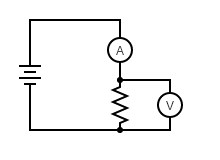

We will assume that our ammeter has a very low voltage drop; this means the voltage across the resistor will be the voltage applied by the power supply.  We can thus simplify our circuit to what is shown below.  Voltage will be "read" by what the power supply outputs, and current will be read by your DMM:

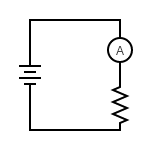

**Whenever practical and possible, determine what you expect your data to look like before you start taking it.  This will help you to identify when something might be wrong with your experimental setup.**

Using Ohm's Law, calculate the current you expect to run through your resistor if 1 V is applied to it.  Enter your answer below.

Expected current, 1.0 V applied:  <span style="background-color:yellow">0.45 mA</span>

Now you will use your power supply to vary the output voltage while measuring the *current through* and *voltage across* the resistor.
To get proper readings you must be sure of the following settings:
* Power supply: Output +/-
* DMM: Current
  * using "I" and "GND" input terminals (lower two on the right)
  * choose the function "DC I" where "I" is for current (this is "Shift" then "DC V")

Use your breadboard to create the simplified circuit above.  Manually take some data for a range of voltages (0-8 V) and measure (and record) the current.

### EXERCISE 3: Plotting I-V data
In the code cell below input your data and then run the appropriate commands to plot your I-V curve. Plot I (vertical axis) vs. V (horizontal axis) and be sure to include labelled axes and show the origin.

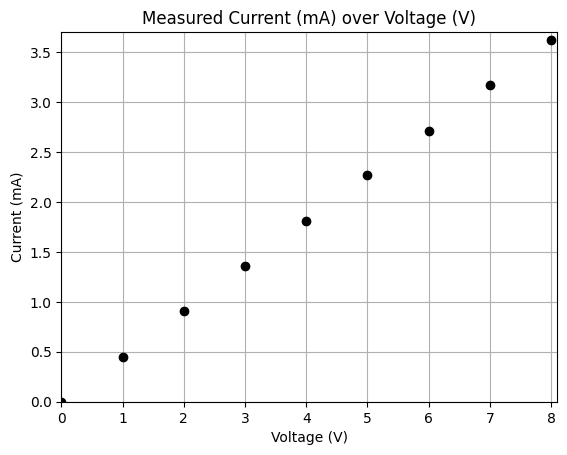

In [2]:
V = [0,1,2,3,4,5,6,7,8]
I = [0,0.452,0.905,1.359,1.812,2.266,2.715,3.169,3.624]

# enter I-V data
# enter commands for plotting I-V data
plt.plot(V,I, "ko")
plt.xlabel('Voltage (V)')
plt.ylabel('Current (mA)')
plt.axis([0,8.1,0,3.7])
plt.title('Measured Current (mA) over Voltage (V)')
plt.grid(True)
# 

In [ ]:
V = [0,1,2,3,4,5,6,7,8]
I = [0,0.452,0.905,1.359,1.812,2.266,2.715,3.169,3.624]

data = pd.DataFrame({'Voltage (V)':V,'Current (A)':I})
data.head()
data.to_csv('I_V_data_16Jan2026.csv', index=False)

## Measure resistance: Computer and ohmmeter (DMM)

We will now begin using the computer to take data.

The `pyvisa` library provides the pathway between the computer and the USB ports and the **General Purpose Interface Bus (GPIB)** which is a set of wires that physically connect the computer to the instruments. (Look on the back of your instruments and find a small gray box labelled "USB/GPIB Interface", that is where the magic happens.)  It also allows you to talk with an instrument connected to the USB port (oscilloscope). We have already made the `pyvisa` package available with our earlier `import` statement.

Now we tell the computer to scan the interfaces and see what's out there.
* Manually turn on both the Power Supply and the DMM.  Turn the output "On" on the Power Supply (with 0 V).

Run the following commands. The first looks to see what interfaced resources are out there and the second prints a list of those resources.

In [2]:
rm = pyvisa.ResourceManager() # see what is out there
rm.list_resources()  # make a list of instruments found

('GPIB0::22::INSTR',
 'GPIB0::5::INSTR',
 'USB0::0x0957::0x179B::MY52166484::0::INSTR')

The specific addresses correspond to the different instruments. Here is the chart for future use:
|instrument|address|
|----------|-------|
|DMM       |'GPIB1::22::INSTR'|
|power supply|'GPIB1::5::INSTR'|
|waveform generator|'GPIB1::10::INSTR'|
|oscilloscope|'USB0::0x0957::0x179B::MY52498198::0::INSTR'|

There should be labels on each instrument.  **NOTE: The 'GPIB1' might be a 'GPIB0'**.

Let's see if we can talk to our DMM.  We will assign the label `dmm` to the resource by providing the address using the `open_resource` command to create a pathway for discussion. We then `query` (ask a question of) the DMM using `dmm.query`, asking it to identify itself using `"IDN?"`. Note that a query has a `?` in the question.

In [3]:
dmm = rm.open_resource('GPIB0::22::INSTR')
print(dmm.query("*IDN?"))

HEWLETT-PACKARD,34401A,0,11-5-3



The DMM is there and responded that it is a model 34401A.

Rewire your resistor to the DMM the way it was wired in Exercise 2.  With your resistor connected to the DMM, let's see what it reads by using the `query` command and asking a question of the DMM, specifically "MEASure" the "RESistance", only the UPPERCASE letters are required. To learn the resistance measured we use the `print` command with a string ('R = ') to tell us what is being reported.

In [8]:
myresistance = dmm.query("MEAS:RES?")
print('R = ', myresistance,' ohms')

R =  +2.20263350E+03
  ohms


Resistance (DMM, automated):  <span style="background-color:yellow">2.202 k$\ohm$</span>

Wow! We can take data with the computer. The value obtained should be the same as (or very close to) what you got earlier in Exercise 2.

Now that we can read the DMM, let's develop an automated I-V curve tracer.

# I-V: automated measurements
The goal is to use our ability to talk to instruments to create an I-V curve using the computer. The process will be 
* set the output voltage on the power supply
* read the corresponding current through the DUT, a resistor for now
(This will be done using the same simplified circuit you used for Exercise 3.)

BY HAND, set the power supply output voltage to 1.0 V and read the corresponding DC current. Be sure your connections are all correct:
* Power supply: +/- output from power supply,
* DMM
  * correct terminals on the DMM to measure current (lower two on the right)
  * Did you get the correct current? (You'll need to press 'LOCAL' to make the buttons work, then put it in 'DC I' mode.)

Does your DMM read your expected current? <span style="background-color:yellow">Yes</span>

We'll need to reestablish a connection with the DMM after putting it in 'LOCAL' mode.

In [4]:
dmm = rm.open_resource('GPIB0::22::INSTR')
print(dmm.query("*IDN?"))

HEWLETT-PACKARD,34401A,0,11-5-3



Now let's open a pathway to the power supply and ask it to self identify.

In [5]:
ps = rm.open_resource('GPIB0::5::INSTR')  # note we use "ps" to reference power supply
print(ps.query("*IDN?"))

Agilent Technologies,E3646A,0,1.7-5.0-1.0



You should now see 'Rmt' displayed on the screens the DMM and power supply.

### Setting the output voltage
We can set the voltage by executing a `write` command to the power supply and "APPLying" the voltage we want.

In [12]:
ps.write("APPL 2.3")

10

Your power supply should be showing "2.3 V". In the cell above, change the "2.3" to some other number (0-8 V) and execute the cell again.  

Did the output voltage change as you expected? <span style="background-color:yellow">Yes</span>

### Reading the current
Now that we have set a voltage, let's read the corresponding current. Similar to voltage, we will query the DMM asking to "MEASure" the "CURRent" in "DC" mode. (Again, only the UPPERCASE letters are needed.)

In [13]:
testcurrent = dmm.query("MEAS:CURR:DC?")
print('I = ',testcurrent)

I =  +1.04279970E-03



Now we have the current.

## Using a "loop" to do something many times
We want to change the voltage and measure the corresponding current _many_ times.  Our computer is happy to do things repetitively.  We will make a list of voltages (`myvoltages`), then we will iterate through the list using `for setvoltage in myvoltages:`. The power supply expects a string, so we add the command "APPLy" to the setvoltage as string and send it to the power supply with the command `write`. For each voltage we will read the current using `query`. 

In [14]:
myvoltages = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
mycurrents = [ ]
dmm.write("*RST") # reset the DMM since we are changing modes
for setvoltage in myvoltages:
    voltagestr = "APPL " + str(setvoltage) + ", 1.0"  # change real (float) to string
    ps.write(voltagestr)
    readcurrentstr = dmm.query("MEAS:CURR:DC?", 1)
    mycurrents.append(float(readcurrentstr)) # change string to real (float)
print(myvoltages)
print(mycurrents)

[0. 1. 2. 3. 4. 5. 6. 7. 8.]
[4.965e-07, 0.0004536589, 0.0009067924, 0.001359633, 0.0018128007, 0.002266092, 0.0027197123, 0.0031730644, 0.0036265906]


So these are the voltages we set and the measured currents. Turn the output of your power supply back to zero once you're done, then plot and save the I-V curve. 

In [38]:
ps.write("APPL 0.0")

10

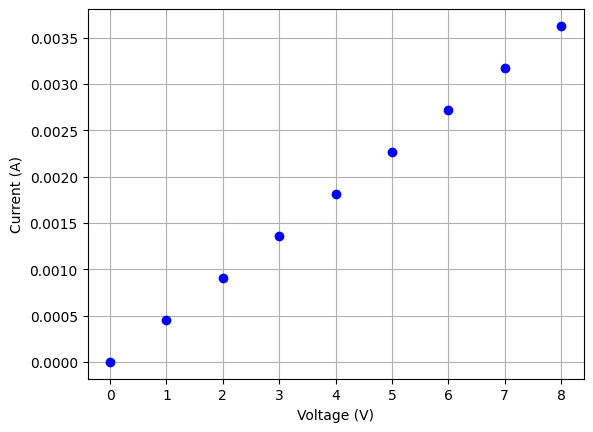

In [16]:
plt.plot(myvoltages,mycurrents,'bo')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.grid(True)
plt.savefig('I_V_curve_resisitor.png') # save the figure as '.png' format

You should also get in the habit of saving your data.  (You might need it to answer your post-lab questions.)

In [17]:
df = []
df = pd.DataFrame(myvoltages)
df.to_csv('lab1_resistorvoltages_16Jan2026.csv', index = False)

df = []
df = pd.DataFrame(mycurrents)
df.to_csv('lab1_resistorcurrents_16Jan2026.csv', index = False)

Let's do a linear best fit and see what we get.  The command is `linregress` and it's in the `stats` portion of the `scipy` library. It is called with `sp.stats.linregress(xvalues, yvalues)`. (Recall that we already imported the `scipy` library as `sp`). The fitting command returns the slope, slope uncertainty in `results.slope` and `results.stderr` and similar for the y-intercept.

In [18]:
results = sp.stats.linregress(myvoltages,mycurrents)
print('slope = ',results.slope,' +/- ',results.stderr)
print('intercept = ',results.intercept,' +/- ',results.intercept_stderr)

slope =  0.00045324819499999993  +/-  4.063804455952409e-08
intercept =  2.1175333333339243e-07  +/-  1.9347579113185094e-07


Now let's find the resistance.  Since we plotted I vs V we can use Ohm's Law ($ V = IR$) to see that $R =V/I$.  This means that for an I-V curve the resistance is the inverse of the slope.

In [19]:
R = 1/results.slope
print('R = ',R,' ohms')

R =  2206.2967068186563  ohms


Resistance (I-V Curve, automated):  <span style="background-color:yellow">2.206 k$\ohm$ </span>

Finally, let's plot our fit along with the data, $I = slope V + intercept = (1/R) V + intercept$.


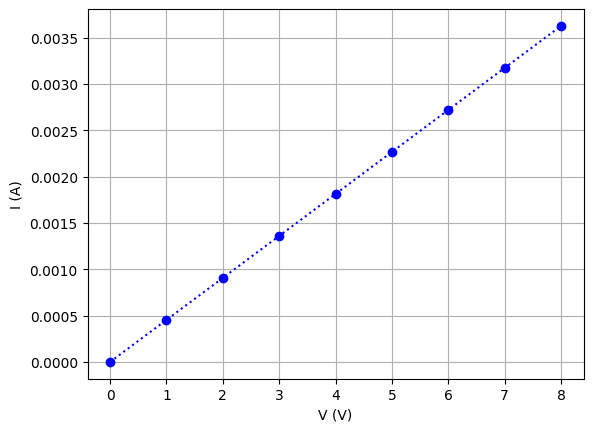

In [20]:
fitcurrents = results.slope*myvoltages + results.intercept
plt.plot(myvoltages,mycurrents,'bo') #plots data as dots
plt.plot(myvoltages,fitcurrents,'b:') #plots fit as dashed line
plt.xlabel('V (V)')
plt.ylabel('I (A)')
plt.grid(True)
plt.savefig('I_V_curve_resistor_withfit.png') # save the figure as '.png' format

## Measuring I-V for different devices

### But First... Limiting Voltages and Currents

Devices (like resistors, bulbs, diodes, etc...) will break (read: burn) if you run too much power through them.  Often a device will have a maximum power, voltage, and/or current that it can tolerate; you will need to look these up.  Note that power, $P$ is given in terms of current $I$ and voltage $V$ as $P=IV$.  For an Ohmic device (one for which $V=IR$), we can write $P=I^2R$ or $P=V^2/R$.

Resistors like the one you just used are fairly robust.  Their power rating (maximum power they can tolerate) depends on their size, and is typically between $1/8 \,\text{W}$ and $1\,\text{W}$.  You may have to look up a device's power rating (usually a quick Google search will do) as many of these devices are too small to write specifications on. 

When you tested your IV curve above, were you below the wattage max for your resistor?  <span style="background-color:yellow">Yes</span>

Below, we will ask you to measure IV curves for a lightbulb and a diode.  Your lightbulb is a "type 46," and your diode is a 1N4001.  Look up the maximum power or voltage ratings for these devices and report the maximum voltage you plan to apply to each below.

Maximum Voltage for type 46 lightbulb:  <span style="background-color:yellow">6.3 Volts</span>
<br>
Maximum Voltage for 1N4001 diode:  <span style="background-color:yellow">1.2 Volts</span>

### I-V Curve for a Lightbulb

Using the techniques and commands introduced above, repeat the experiment for a type 46 lightbulb.  Put your commands below and run the cell.  Be sure to save any data and plots.

In [29]:
# commands for I-V curve of bulb
myvoltages = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
mycurrents = [ ]
dmm.write("*RST") # reset the DMM since we are changing modes
for setvoltage in myvoltages:
    voltagestr = "APPL " + str(setvoltage) + ", 1.0"  # change real (float) to string
    ps.write(voltagestr)
    readcurrentstr = dmm.query("MEAS:CURR:DC?", 1)
    mycurrents.append(float(readcurrentstr)) # change string to real (float)
print(myvoltages)
print(mycurrents)

[0. 1. 2. 3. 4. 5. 6. 7. 8.]
[0.0001373828, 0.22679042, 0.16662081, 0.18193121, 0.20740634, 0.23108426, 0.25505092, 0.27625451, 0.29640235]


In [23]:
df = []
df = pd.DataFrame(myvoltages)
df.to_csv('lab1_lightbulbvoltages_16Jan2026.csv', index = False)

df = []
df = pd.DataFrame(mycurrents)
df.to_csv('lab1_lightbulbcurrents_16Jan2026.csv', index = False)

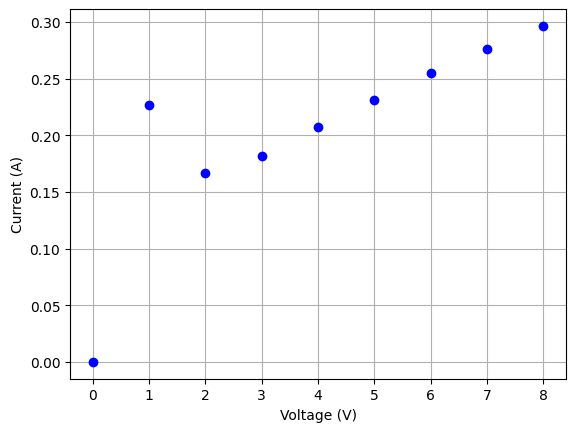

In [30]:
plt.plot(myvoltages,mycurrents,'bo')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.grid(True)
plt.savefig('I_V_curve_lightbulb.png')

In [25]:
results = sp.stats.linregress(myvoltages,mycurrents)
print('slope = ',results.slope,' +/- ',results.stderr)
print('intercept = ',results.intercept,' +/- ',results.intercept_stderr)

slope =  0.026266768059999997  +/-  0.006853613693582795
intercept =  0.09903783266  +/-  0.032629727779735156


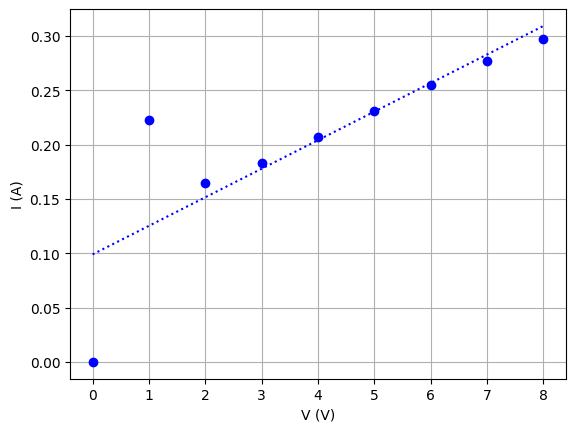

In [26]:
fitcurrents = results.slope*myvoltages + results.intercept
plt.plot(myvoltages,mycurrents,'bo') #plots data as dots
plt.plot(myvoltages,fitcurrents,'b:') #plots fit as dashed line
plt.xlabel('V (V)')
plt.ylabel('I (A)')
plt.grid(True)
plt.savefig('I_V_curve_lightbulb_withfit.png')

After plotting your I-V curve for the lightbulb, you might notice that some of the points seem anomalous.  Try to take your data differently to see if any of the anomalous data resolves.  You might try sweeping the voltage from high to low (instead of low to high), and/or putting a time delay of a couple of seconds between each reading.  To add a time delay, you will need to `import` the package `time` and use the command `time.sleep(enternumberofsecondshere)`.  Comment on whether or not your measurement method affects your data. 

In [42]:
# commands for I-V curve of a lightbulb with high-to-low voltage sweep
myvoltages = np.array([8.0, 7.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.0])
mycurrents = [ ]
dmm.write("*RST") # reset the DMM since we are changing modes
for setvoltage in myvoltages:
    voltagestr = "APPL " + str(setvoltage) + ", 1.0"  # change real (float) to string
    ps.write(voltagestr)
    readcurrentstr = dmm.query("MEAS:CURR:DC?", 1)
    mycurrents.append(float(readcurrentstr)) # change string to real (float)
print(myvoltages)
print(mycurrents)

[8. 7. 6. 5. 4. 3. 2. 1. 0.]
[0.29742987, 0.27112098, 0.2478023, 0.2224951, 0.19310613, 0.16147616, 0.12436335, 0.055750505, 8.42746e-05]


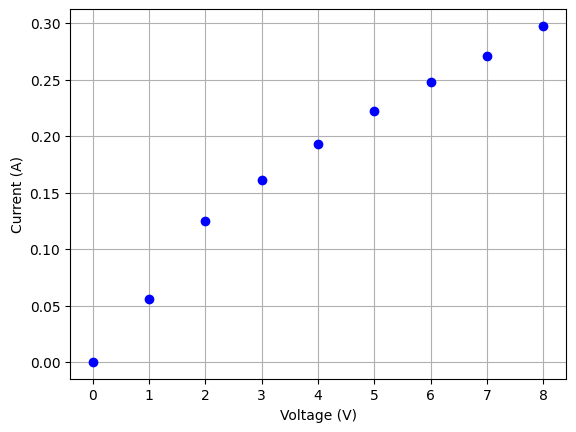

In [43]:
plt.plot(myvoltages,mycurrents,'bo')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.grid(True)
plt.savefig('I_V_curve_lightbulb(high-low).png')

In [35]:
results = sp.stats.linregress(myvoltages,mycurrents)
print('slope = ',results.slope,' +/- ',results.stderr)
print('intercept = ',results.intercept,' +/- ',results.intercept_stderr)

slope =  0.035583096210000005  +/-  0.00265213797795068
intercept =  0.03102452150444443  +/-  0.012626702368103423


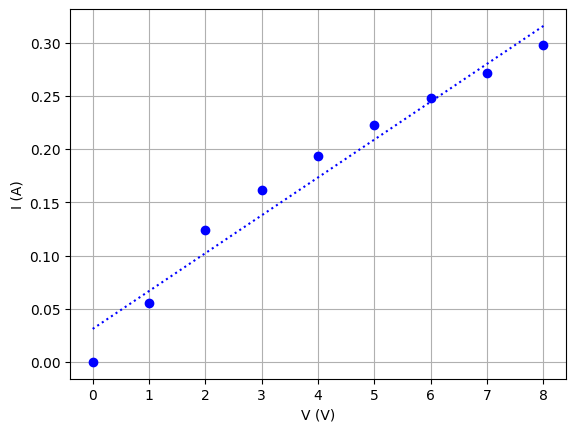

In [44]:
fitcurrents = results.slope*myvoltages + results.intercept
plt.plot(myvoltages,mycurrents,'bo') #plots data as dots
plt.plot(myvoltages,fitcurrents,'b:') #plots fit as dashed line
plt.xlabel('V (V)')
plt.ylabel('I (A)')
plt.grid(True)
plt.savefig('I_V_curve_lightbulb(high-low)_withfit.png')

In [45]:
import time

# commands for I-V curve of a lightbulb with a time delay at each reading
myvoltages = np.array([8.0, 7.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.0])
mycurrents = [ ]
dmm.write("*RST") # reset the DMM since we are changing modes
for setvoltage in myvoltages:
    voltagestr = "APPL " + str(setvoltage) + ", 1.0"  # change real (float) to string
    ps.write(voltagestr)
    readcurrentstr = dmm.query("MEAS:CURR:DC?", 1)
    mycurrents.append(float(readcurrentstr)) # change string to real (float)
    time.sleep(4)
print(myvoltages)
print(mycurrents)

[8. 7. 6. 5. 4. 3. 2. 1. 0.]
[0.29742888, 0.27082243, 0.2479452, 0.2220092, 0.19318092, 0.16034599, 0.12354658, 0.055843025, 8.7578e-05]


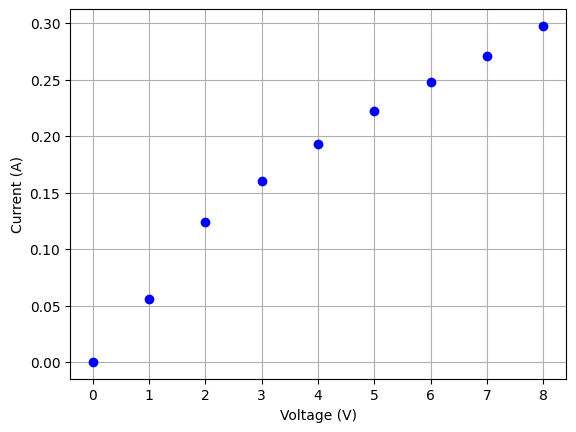

In [48]:
plt.plot(myvoltages,mycurrents,'bo')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.grid(True)
plt.savefig('I_V_curve_lightbulb(high-low)(time=4).png')

In [47]:
results = sp.stats.linregress(myvoltages,mycurrents)
print('slope = ',results.slope,' +/- ',results.stderr)
print('intercept = ',results.intercept,' +/- ',results.intercept_stderr)

slope =  0.03574606454999999  +/-  0.0026809078787923242
intercept =  0.031594608800000035  +/-  0.012763674493274675


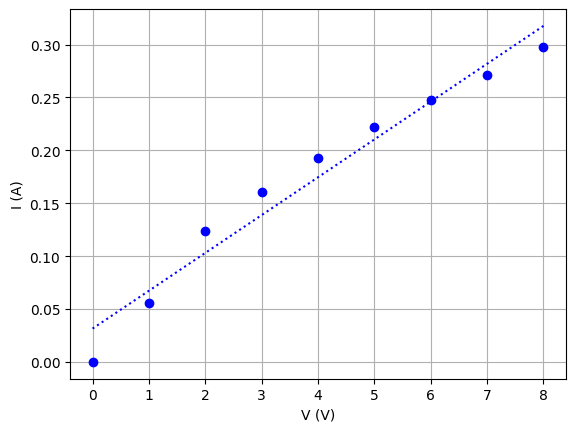

In [49]:
fitcurrents = results.slope*myvoltages + results.intercept
plt.plot(myvoltages,mycurrents,'bo') #plots data as dots
plt.plot(myvoltages,fitcurrents,'b:') #plots fit as dashed line
plt.xlabel('V (V)')
plt.ylabel('I (A)')
plt.grid(True)
plt.savefig('I_V_curve_lightbulb(high-low)(time=4)_withfit.png')

### I-V Curve for a Diode

Using the techniques and commands introduced above, repeat the experiment for a 1N4001 diode.  Put your commands below and run the cell.  Be sure to save any data and plots.

Note:  Unlike most bulbs and resistors, diodes have polarity, meaning they have a '+' end and a '-' end, where positive current flows from '+' to '-'.  The '-' end is the end with the large silver band, and should be closest to ground in your circuit.  

In the PostLab, I will ask you to compare your data with that of some of your labmates.  This is made easier if everyone measures current at the same values of voltage.  A nice way to do this is to use a command in `numpy` called `np.linspace()`.  (Recall that you abbreviated `numpy` to `np` when you imported it above.)  The syntax for `np.linspace()` is `np.linspace(start, stop, num=numberofpoints)`.  

Let's try a quick example.  Let's say you want 10 evenly spaced data points between 0 and 5.  Try running the code below.

In [ ]:
testlist = []
testlist = np.linspace(0, 5, num=10)
print(testlist)

In [32]:
# commands for I-V curve of diode
myVoltages = np.linspace(0,1.2,20)
myvoltages = np.ndarray.tolist(myVoltages)
mycurrents = [ ]
dmm.write("*RST") # reset the DMM since we are changing modes
for setvoltage in myvoltages:
    voltagestr = "APPL " + str(setvoltage) + ", 1.0"  # change real (float) to string
    ps.write(voltagestr)
    readcurrentstr = dmm.query("MEAS:CURR:DC?", 1)
    mycurrents.append(float(readcurrentstr)) # change string to real (float)
print(myvoltages)
print(mycurrents)
# Take 20 data points between 0 and 1.2V
#

[0.0, 0.06315789473684211, 0.12631578947368421, 0.18947368421052632, 0.25263157894736843, 0.3157894736842105, 0.37894736842105264, 0.4421052631578948, 0.5052631578947369, 0.5684210526315789, 0.631578947368421, 0.6947368421052632, 0.7578947368421053, 0.8210526315789474, 0.8842105263157896, 0.9473684210526316, 1.0105263157894737, 1.0736842105263158, 1.1368421052631579, 1.2]
[-5.81e-08, -7.3e-09, -2.66e-08, 5.33e-08, 4.601e-07, 2.8456e-06, 1.65314e-05, 8.59457e-05, 0.0003603773, 0.0012806403, 0.0036438776, 0.007998212, 0.014093187, 0.021355353, 0.11751286, 0.1642624, 0.21691504, 0.26565698, 0.31720634, 0.37107821]


In [21]:
ps.write("APPL 0.0")

10

In [33]:
df = []
df = pd.DataFrame(myvoltages)
df.to_csv('lab1_diodevoltages_20Jan2026.csv', index = False)

df = []
df = pd.DataFrame(mycurrents)
df.to_csv('lab1_diodecurrents_20Jan2026.csv', index = False)

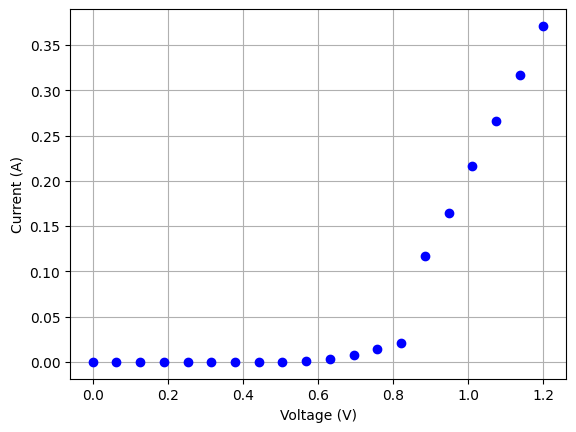

In [34]:
plt.plot(myvoltages,mycurrents,'bo')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.grid(True)
plt.savefig('I_V_curve_diode.png')

In [6]:
import pandas as pd

df = pd.read_csv('lab1_diodevoltages_20Jan2026.csv')
my_voltages = [df[x].values.tolist() for x in df.columns][0]
df = pd.read_csv('lab1_diodecurrents_20Jan2026.csv')
my_currents = [df[x].values.tolist() for x in df.columns][0]

print(my_voltages)
print(my_currents)

[0.0, 0.0631578947368421, 0.1263157894736842, 0.1894736842105263, 0.2526315789473684, 0.3157894736842105, 0.3789473684210526, 0.4421052631578948, 0.5052631578947369, 0.5684210526315789, 0.631578947368421, 0.6947368421052632, 0.7578947368421053, 0.8210526315789474, 0.8842105263157896, 0.9473684210526316, 1.0105263157894735, 1.0736842105263158, 1.136842105263158, 1.2]
[-5.81e-08, -7.3e-09, -2.66e-08, 5.33e-08, 4.601e-07, 2.8456e-06, 1.65314e-05, 8.59457e-05, 0.0003603773, 0.0012806403, 0.0036438776, 0.007998212, 0.014093187, 0.021355353, 0.11751286, 0.1642624, 0.21691504, 0.26565698, 0.31720634, 0.37107821]


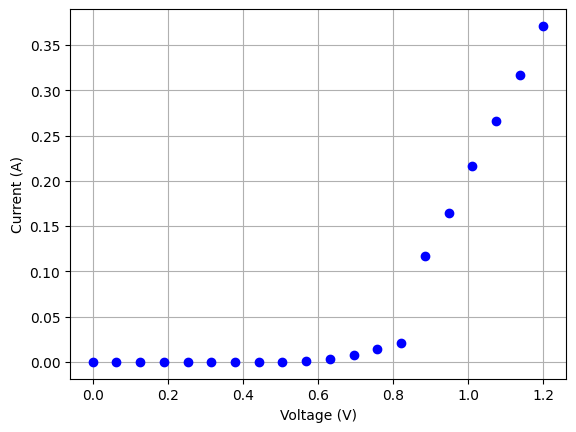

In [9]:
plt.plot(my_voltages,my_currents,'bo')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.grid(True)

In [10]:
results = sp.stats.linregress(my_voltages,my_currents)
print('slope = ',results.slope,' +/- ',results.stderr)
print('intercept = ',results.intercept,' +/- ',results.intercept_stderr)

slope =  0.26615358442500003  +/-  0.04503592870683766
intercept =  -0.08461868959  +/-  0.0316096907402592


In [44]:
myVoltages = np.linspace(1.2,0,num=20)
myvoltages = np.ndarray.tolist(myVoltages)
mycurrents = [ ]
dmm.write("*RST") # reset the DMM since we are changing modes
for setvoltage in myvoltages:
    voltagestr = "APPL " + str(setvoltage) + ", 1.0"  # change real (float) to string
    ps.write(voltagestr)
    readcurrentstr = dmm.query("MEAS:CURR:DC?", 1)
    mycurrents.append(float(readcurrentstr)) # change string to real (float)
print(myvoltages)
print(mycurrents)

[1.2, 1.1368421052631579, 1.0736842105263158, 1.0105263157894737, 0.9473684210526315, 0.8842105263157894, 0.8210526315789473, 0.7578947368421052, 0.6947368421052631, 0.631578947368421, 0.5684210526315789, 0.5052631578947367, 0.44210526315789467, 0.3789473684210526, 0.3157894736842104, 0.2526315789473683, 0.18947368421052624, 0.12631578947368416, 0.06315789473684208, 0.0]
[0.38166397, 0.3354975, 0.28352962, 0.22864151, 0.17725113, 0.12790137, 0.021757354, 0.014002314, 0.0075794846, 0.0031522875, 0.0009677764, 0.0002319528, 4.46463e-05, 6.9046e-06, 9.082e-07, 1.429e-07, 9.7e-09, -3.63e-08, -4.36e-08, -2.42e-08]


In [46]:
df = []
df = pd.DataFrame(myvoltages)
df.to_csv('lab1_diodevoltages_high-low_20Jan2026.csv', index = False)

df = []
df = pd.DataFrame(mycurrents)
df.to_csv('lab1_diodecurrents_high-low_20Jan2026.csv', index = False)

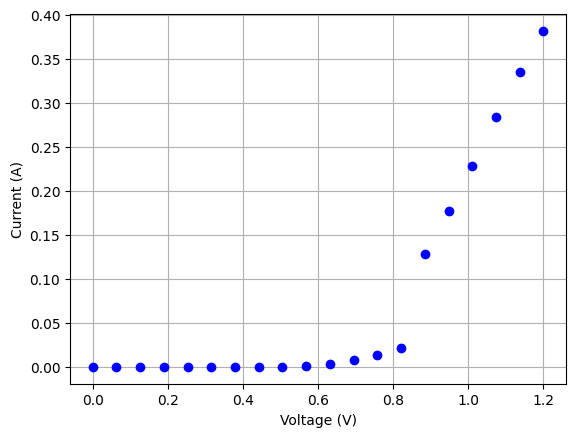

In [45]:
plt.plot(myvoltages,mycurrents,'bo')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.grid(True)
plt.savefig('I_V_curve_diode(high-low).png')

In [47]:
import time

myVoltages = np.linspace(1.2,0,num=20)
myvoltages = np.ndarray.tolist(myVoltages)
mycurrents = [ ]
dmm.write("*RST") # reset the DMM since we are changing modes
for setvoltage in myvoltages:
    voltagestr = "APPL " + str(setvoltage) + ", 1.0"  # change real (float) to string
    ps.write(voltagestr)
    readcurrentstr = dmm.query("MEAS:CURR:DC?", 1)
    mycurrents.append(float(readcurrentstr)) # change string to real (float)
    time.sleep(2)
print(myvoltages)
print(mycurrents)

[1.2, 1.1368421052631579, 1.0736842105263158, 1.0105263157894737, 0.9473684210526315, 0.8842105263157894, 0.8210526315789473, 0.7578947368421052, 0.6947368421052631, 0.631578947368421, 0.5684210526315789, 0.5052631578947367, 0.44210526315789467, 0.3789473684210526, 0.3157894736842104, 0.2526315789473683, 0.18947368421052624, 0.12631578947368416, 0.06315789473684208, 0.0]
[0.36581083, 0.32506469, 0.27500522, 0.22566594, 0.17289106, 0.12471514, 0.021126402, 0.013157112, 0.0067915325, 0.0026350987, 0.0007420573, 0.000164282, 2.87834e-05, 4.2987e-06, 4.868e-07, 2.91e-08, 7.3e-09, 1.45e-08, 2.91e-08, -4.12e-08]


In [48]:
df = []
df = pd.DataFrame(myvoltages)
df.to_csv('lab1_diodevoltages_high-low_time=2_20Jan2026.csv', index = False)

df = []
df = pd.DataFrame(mycurrents)
df.to_csv('lab1_diodecurrents_high-low_time=2_20Jan2026.csv', index = False)

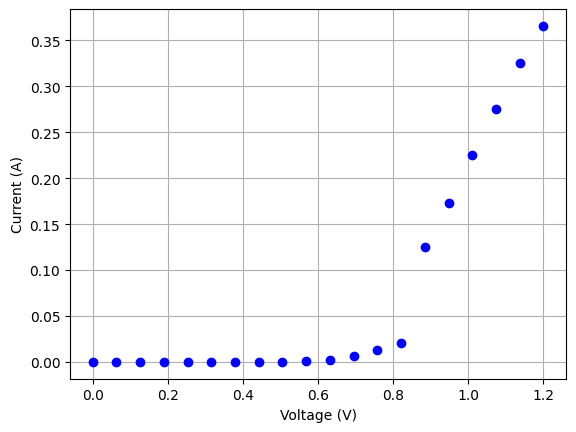

In [49]:
plt.plot(myvoltages,mycurrents,'bo')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.grid(True)
plt.savefig('I_V_curve_diode(high-low)(time=2).png')

Lastly, get diode data from at least two other classmates.  You will need it for your PostLab.

In [4]:
#Sophia's Diode data
sophiavoltages = np.linspace(0,1.2,num=20)
sophiacurrents = [-2.29e-08, -5.35e-08, -8.41e-08, 8.41e-08, 5.912e-07, 2.4438e-06, 1.40945e-05, 6.51211e-05, 0.0002525033, 0.0008659649, 0.0025549401, 0.0060365875, 0.011387743, 0.018089304, 0.025768267, 0.1269622, 0.17000757, 0.21532906, 0.2620609, 0.30978028]


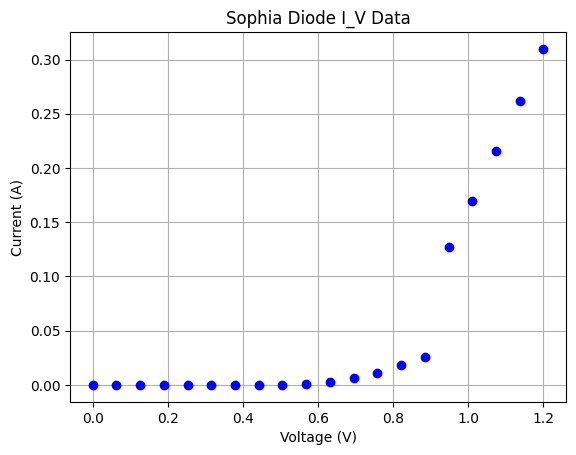

In [5]:
plt.plot(sophiavoltages,sophiacurrents,'bo')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.title('Sophia Diode I_V Data')
plt.grid(True)
plt.savefig('I_V_curve_diode_Sophia.png')

In [9]:
#Alina's Diode Data
alinavoltages = np.linspace(0, 1.2, num=20)
alinacurrents = [7.7e-09, 6.18e-08, 1.39e-07, 4.736e-07, 1.8248e-06, 7.4511e-06, 3.28722e-05, 0.0001383712, 0.0005039557, 0.0015573102, 0.004033055, 0.0084163718, 0.014548848, 0.021851049, 0.029928682, 0.18426234, 0.24284491, 0.30656198, 0.37321251, 0.44378173]

print(alinavoltages)
print(alinacurrents)

[0.         0.06315789 0.12631579 0.18947368 0.25263158 0.31578947
 0.37894737 0.44210526 0.50526316 0.56842105 0.63157895 0.69473684
 0.75789474 0.82105263 0.88421053 0.94736842 1.01052632 1.07368421
 1.13684211 1.2       ]
[7.7e-09, 6.18e-08, 1.39e-07, 4.736e-07, 1.8248e-06, 7.4511e-06, 3.28722e-05, 0.0001383712, 0.0005039557, 0.0015573102, 0.004033055, 0.0084163718, 0.014548848, 0.021851049, 0.029928682, 0.18426234, 0.24284491, 0.30656198, 0.37321251, 0.44378173]


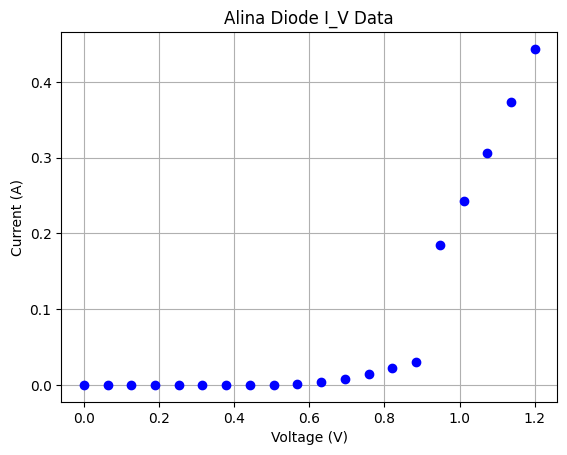

In [10]:
plt.plot(alinavoltages,alinacurrents,'bo')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.title('Alina Diode I_V Data')
plt.grid(True)
plt.savefig('I_V_curve_diode_Alina.png')